# Homework: TopoDL for MNIST Image Classification

This notebook implements a **Topological Deep Learning (TopoDL)** pipeline for MNIST:

1. Each grayscale image is converted into a cubical filtration.
2. Persistent homology extracts finite $H_0$ and $H_1$ intervals.
3. Persistence intervals are rasterized and cached as persistence images (PI).
4. Three CNN branches independently encode the original image, PI-$H_0$, and PI-$H_1$.
5. The three embedding vectors are concatenated and passed through a linear fusion classifier.

The topology branch gives the classifier explicit information about connected components and loops,
while the image branch preserves the original visual information.


## 1. Install and Import Libraries


In [1]:
# GUDHI provides cubical persistent homology for grayscale images.
# Run this installation cell once when using a fresh Colab or notebook environment.
!pip install -q gudhi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 30.6 MB/s eta 0:00:00


In [2]:
import random
from pathlib import Path

import gudhi as gd
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms
from tqdm.auto import tqdm


## 2. Configuration


In [3]:
SEED = 42

# MNIST and persistence images both use one channel with size 28 x 28.
IMAGE_SIZE = 28
PI_SIZE = 28
NUM_CLASSES = 10

# Persistence-image parameters.
PI_SIGMA = 0.055
PI_MAX_PERSISTENCE = 1.0

# Training hyperparameters.
BATCH_SIZE = 128
EPOCHS = 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EMBEDDING_DIM = 64

# Use subsets for a faster demonstration.
# Set both values to None to extract topology and train on full MNIST.
TRAIN_LIMIT = 10000
TEST_LIMIT = 2000

# Raw MNIST data and cached H0/H1 persistence images are stored separately.
DATA_DIR = Path("./data")
PI_CACHE_DIR = Path("./mnist_pi_cache")
PI_CACHE_DIR.mkdir(parents=True, exist_ok=True)


## 3. Reproducibility and Device


In [4]:
def set_seed(seed: int = SEED) -> None:
    # Fix Python, NumPy, and PyTorch randomness for reproducible experiments.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## 4. Load Raw MNIST Images


In [5]:
# Keep raw intensities in [0, 1]. Normalization is applied only when a sample
# is returned to the original-image CNN branch.
raw_transform = transforms.ToTensor()

train_dataset_full = datasets.MNIST(
    root=DATA_DIR, train=True, transform=raw_transform, download=True
)
test_dataset_full = datasets.MNIST(
    root=DATA_DIR, train=False, transform=raw_transform, download=True
)

train_indices = np.arange(
    len(train_dataset_full) if TRAIN_LIMIT is None else min(TRAIN_LIMIT, len(train_dataset_full))
)
test_indices = np.arange(
    len(test_dataset_full) if TEST_LIMIT is None else min(TEST_LIMIT, len(test_dataset_full))
)

train_raw = Subset(train_dataset_full, train_indices)
test_raw = Subset(test_dataset_full, test_indices)
class_names = [str(digit) for digit in range(NUM_CLASSES)]

print(f"Training samples: {len(train_raw)}")
print(f"Test samples: {len(test_raw)}")


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.01MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.39MB/s]

Training samples: 10000
Test samples: 2000


## 5. Extract Persistent Homology and Create Persistence Images

For a grayscale image $I$, the cubical filtration uses $1-I$. Bright digit pixels therefore enter
the filtration before the dark background. GUDHI extracts persistence intervals from this cubical
complex:

- $H_0$: connected components and their mergers;
- $H_1$: loops or holes inside the digit.

Each finite interval $(birth, death)$ is converted to $(birth, persistence)$, where
$persistence = death-birth$. A weighted Gaussian is placed at each point to create a fixed-size PI.


In [6]:
def extract_cubical_intervals(image: np.ndarray, dimension: int) -> np.ndarray:
    '''Extract finite cubical-persistence intervals for one homology dimension.'''
    # Bright foreground pixels appear early; dark background pixels appear late.
    filtration = 1.0 - np.asarray(image, dtype=np.float64)
    complex_ = gd.CubicalComplex(top_dimensional_cells=filtration)
    complex_.compute_persistence(homology_coeff_field=2, min_persistence=0.0)

    intervals = complex_.persistence_intervals_in_dimension(dimension)
    if len(intervals) == 0:
        return np.empty((0, 2), dtype=np.float32)

    # Essential classes have infinite death and cannot be rasterized into a finite PI.
    intervals = intervals[np.isfinite(intervals[:, 1])]
    return intervals.astype(np.float32)


def intervals_to_persistence_image(
    intervals: np.ndarray,
    size: int = PI_SIZE,
    sigma: float = PI_SIGMA,
    max_persistence: float = PI_MAX_PERSISTENCE,
) -> np.ndarray:
    '''Rasterize birth-persistence points into a weighted Gaussian surface.'''
    if len(intervals) == 0:
        return np.zeros((size, size), dtype=np.float32)

    births = np.clip(intervals[:, 0], 0.0, 1.0)
    persistences = np.clip(intervals[:, 1] - intervals[:, 0], 0.0, max_persistence)

    x = np.linspace(0.0, 1.0, size, dtype=np.float32)
    y = np.linspace(0.0, max_persistence, size, dtype=np.float32)
    xx, yy = np.meshgrid(x, y)
    surface = np.zeros((size, size), dtype=np.float32)

    # Persistence weighting suppresses short-lived topological noise.
    for birth, persistence in zip(births, persistences):
        gaussian = np.exp(
            -((xx - birth) ** 2 + (yy - persistence) ** 2) / (2.0 * sigma**2)
        )
        surface += persistence * gaussian

    # Per-image scaling keeps PI values stable for CNN optimization.
    maximum = float(surface.max())
    if maximum > 0:
        surface /= maximum
    return surface.astype(np.float32)


def image_to_h0_h1_pi(image_tensor: torch.Tensor) -> tuple[np.ndarray, np.ndarray]:
    '''Convert one MNIST tensor into H0 and H1 persistence images.'''
    image = image_tensor.squeeze(0).numpy()
    h0 = extract_cubical_intervals(image, dimension=0)
    h1 = extract_cubical_intervals(image, dimension=1)
    return intervals_to_persistence_image(h0), intervals_to_persistence_image(h1)


## 6. Extract and Save PI-H0 / PI-H1 Features


In [7]:
def build_or_load_pi_cache(
    dataset: Subset,
    cache_path: Path,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    '''Load cached PIs, or extract and save them when the cache does not exist.'''
    if cache_path.exists():
        cached = np.load(cache_path)
        if len(cached["labels"]) == len(dataset):
            print(f"Loaded cached topology: {cache_path}")
            return cached["h0"], cached["h1"], cached["labels"]
        print(f"Ignoring stale cache with a different sample count: {cache_path}")

    h0_images = np.zeros((len(dataset), PI_SIZE, PI_SIZE), dtype=np.float32)
    h1_images = np.zeros_like(h0_images)
    labels = np.zeros(len(dataset), dtype=np.int64)

    for index in tqdm(range(len(dataset)), desc=f"Extracting {cache_path.stem}"):
        image, label = dataset[index]
        h0_images[index], h1_images[index] = image_to_h0_h1_pi(image)
        labels[index] = label

    np.savez_compressed(cache_path, h0=h0_images, h1=h1_images, labels=labels)
    print(f"Saved H0/H1 persistence images to: {cache_path.resolve()}")
    return h0_images, h1_images, labels


# The cache filenames include the subset size and PI size to avoid accidental mismatch.
train_cache_path = PI_CACHE_DIR / f"train_n{len(train_raw)}_pi{PI_SIZE}.npz"
test_cache_path = PI_CACHE_DIR / f"test_n{len(test_raw)}_pi{PI_SIZE}.npz"

train_h0, train_h1, train_labels = build_or_load_pi_cache(train_raw, train_cache_path)
test_h0, test_h1, test_labels = build_or_load_pi_cache(test_raw, test_cache_path)

print(f"Train H0 PI shape: {train_h0.shape}")
print(f"Train H1 PI shape: {train_h1.shape}")


Extracting train_n10000_pi28:   0%|          | 0/10000 [00:00<?, ?it/s]

Saved H0/H1 persistence images to: /content/mnist_pi_cache/train_n10000_pi28.npz


Extracting test_n2000_pi28:   0%|          | 0/2000 [00:00<?, ?it/s]

Saved H0/H1 persistence images to: /content/mnist_pi_cache/test_n2000_pi28.npz
Train H0 PI shape: (10000, 28, 28)
Train H1 PI shape: (10000, 28, 28)


## 7. Visualize Original Images, PI-H0, and PI-H1 for 10 Samples


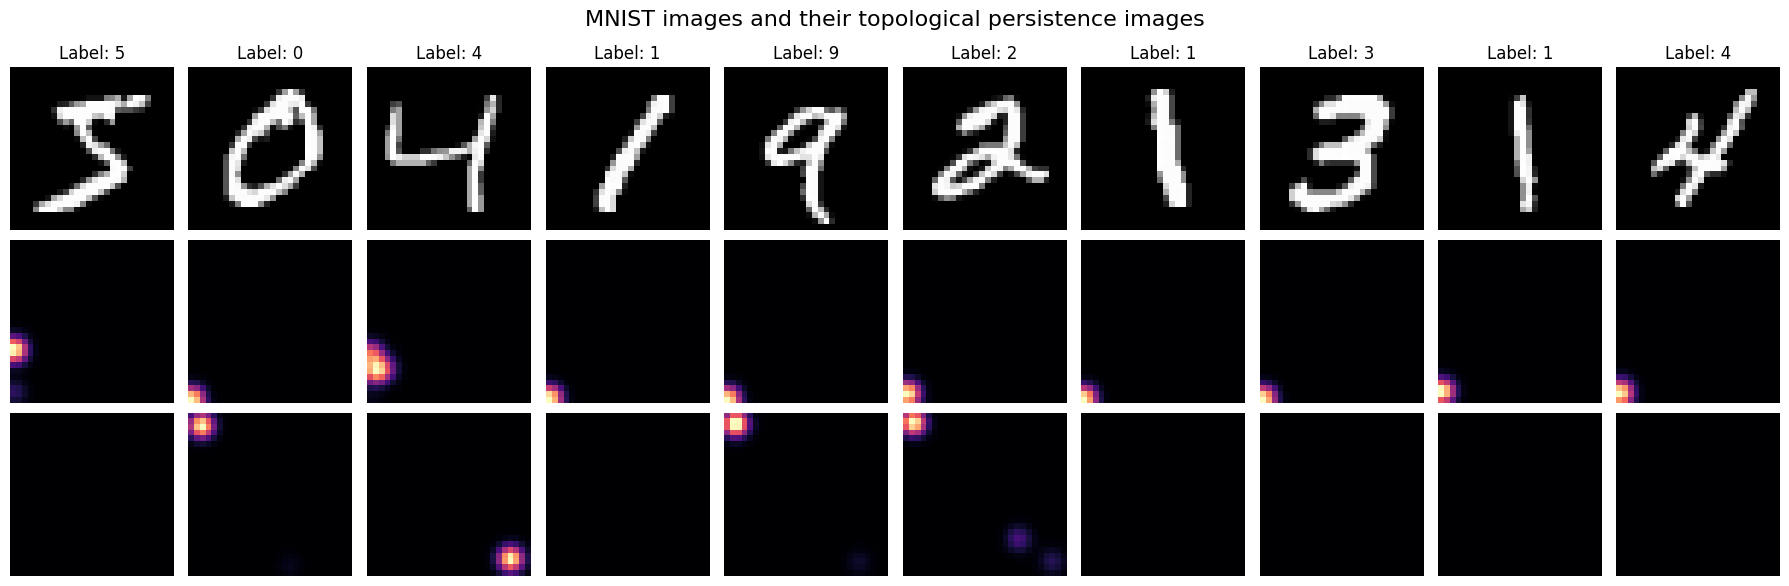

In [8]:
fig, axes = plt.subplots(3, 10, figsize=(18, 6))

for index in range(10):
    image, label = train_raw[index]

    axes[0, index].imshow(image.squeeze(0), cmap="gray")
    axes[0, index].set_title(f"Label: {label}")
    axes[1, index].imshow(train_h0[index], cmap="magma", origin="lower")
    axes[2, index].imshow(train_h1[index], cmap="magma", origin="lower")

    for row in range(3):
        axes[row, index].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("PI H0", fontsize=12)
axes[2, 0].set_ylabel("PI H1", fontsize=12)
plt.suptitle("MNIST images and their topological persistence images", fontsize=16)
plt.tight_layout()
plt.show()


## 8. Create a Three-Input TopoDL Dataset and DataLoaders


In [9]:
class TopologicalMNISTDataset(Dataset):
    '''Return the original MNIST image together with its cached H0 and H1 PIs.'''

    def __init__(self, raw_dataset: Subset, h0_images: np.ndarray, h1_images: np.ndarray):
        if not (len(raw_dataset) == len(h0_images) == len(h1_images)):
            raise ValueError("Raw images, H0 PIs, and H1 PIs must have equal lengths.")
        self.raw_dataset = raw_dataset
        self.h0_images = h0_images
        self.h1_images = h1_images

    def __len__(self) -> int:
        return len(self.raw_dataset)

    def __getitem__(self, index: int):
        image, label = self.raw_dataset[index]

        # Apply standard MNIST normalization only to the original-image branch.
        normalized_image = (image - 0.1307) / 0.3081
        h0 = torch.from_numpy(self.h0_images[index]).unsqueeze(0)
        h1 = torch.from_numpy(self.h1_images[index]).unsqueeze(0)
        return normalized_image.float(), h0.float(), h1.float(), label


train_dataset = TopologicalMNISTDataset(train_raw, train_h0, train_h1)
test_dataset = TopologicalMNISTDataset(test_raw, test_h0, test_h1)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch_image, batch_h0, batch_h1, batch_labels = next(iter(train_loader))
print("Original image batch:", batch_image.shape)
print("PI-H0 batch:", batch_h0.shape)
print("PI-H1 batch:", batch_h1.shape)
print("Label batch:", batch_labels.shape)


Original image batch: torch.Size([128, 1, 28, 28])
PI-H0 batch: torch.Size([128, 1, 28, 28])
PI-H1 batch: torch.Size([128, 1, 28, 28])
Label batch: torch.Size([128])


## 9. Define the Three-Branch TopoDL CNN with Linear Fusion


In [10]:
class CNNEncoder(nn.Module):
    '''Encode one single-channel image into a compact embedding vector.'''

    def __init__(self, embedding_dim: int = EMBEDDING_DIM) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, embedding_dim),
            nn.ReLU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.projection(self.features(x))


class TopoDLMNISTClassifier(nn.Module):
    '''Fuse original-image, H0-PI, and H1-PI CNN embeddings for classification.'''

    def __init__(self, embedding_dim: int, num_classes: int) -> None:
        super().__init__()
        self.image_cnn = CNNEncoder(embedding_dim)
        self.h0_cnn = CNNEncoder(embedding_dim)
        self.h1_cnn = CNNEncoder(embedding_dim)

        # Concatenate the three vectors, then learn a linear fusion representation.
        self.fusion = nn.Sequential(
            nn.Linear(embedding_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes),
        )

    def forward(
        self,
        image: torch.Tensor,
        h0_pi: torch.Tensor,
        h1_pi: torch.Tensor,
    ) -> torch.Tensor:
        image_embedding = self.image_cnn(image)
        h0_embedding = self.h0_cnn(h0_pi)
        h1_embedding = self.h1_cnn(h1_pi)
        fused_embedding = torch.cat(
            [image_embedding, h0_embedding, h1_embedding], dim=1
        )
        return self.fusion(fused_embedding)


model = TopoDLMNISTClassifier(embedding_dim=EMBEDDING_DIM, num_classes=NUM_CLASSES)
print(model)


TopoDLMNISTClassifier(
  (image_cnn): CNNEncoder(
    (features): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): AdaptiveAvgPool2d(output_size=(1, 1))
    )
    (projection): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=64, out_features=64, bias=True)


## 10. Move Model to Device and Initialize Optimization


In [11]:
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)

num_trainable = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f"Total trainable parameters: {num_trainable:,}")
print(f"Optimizer: {optimizer.__class__.__name__}")


Total trainable parameters: 109,034
Optimizer: AdamW


## 11. Training and Evaluation Helpers


In [12]:
def move_batch_to_device(batch, device):
    image, h0, h1, labels = batch
    return image.to(device), h0.to(device), h1.to(device), labels.to(device)


def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch in dataloader:
        image, h0, h1, labels = move_batch_to_device(batch, device)
        logits = model(image, h0, h1)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    for batch in dataloader:
        image, h0, h1, labels = move_batch_to_device(batch, device)
        logits = model(image, h0, h1)
        loss = criterion(logits, labels)
        predictions = logits.argmax(dim=1)

        total_loss += loss.item() * labels.size(0)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return (
        total_loss / total,
        correct / total,
        np.asarray(all_predictions),
        np.asarray(all_labels),
    )


## 12. Train the TopoDL Classifier


In [13]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f} | "
        f"Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}"
    )


Epoch 01/5 | Train loss: 1.5298, Train acc: 0.4721 | Test loss: 1.0732, Test acc: 0.6020
Epoch 02/5 | Train loss: 0.6286, Train acc: 0.7993 | Test loss: 0.9516, Test acc: 0.6550
Epoch 03/5 | Train loss: 0.3853, Train acc: 0.8875 | Test loss: 0.3948, Test acc: 0.8835
Epoch 04/5 | Train loss: 0.2827, Train acc: 0.9188 | Test loss: 0.6219, Test acc: 0.8020
Epoch 05/5 | Train loss: 0.2224, Train acc: 0.9359 | Test loss: 0.3372, Test acc: 0.8970


## 13. Plot Training History


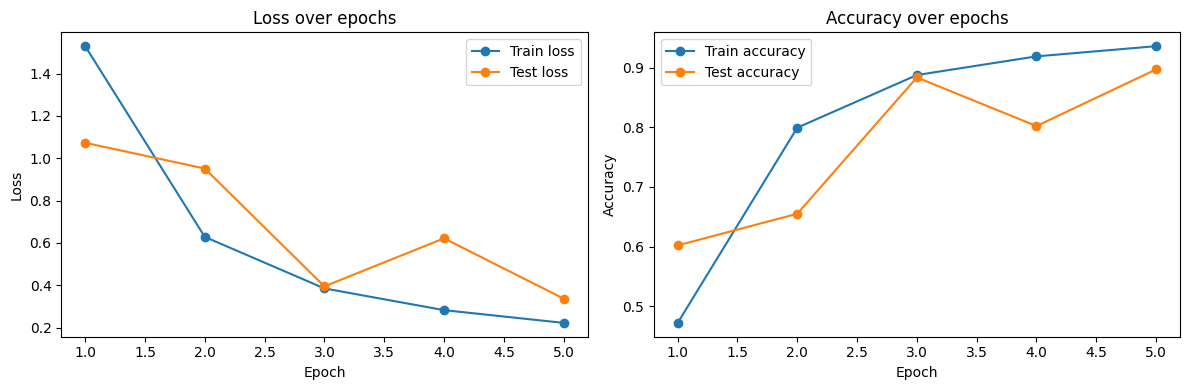

In [14]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Train loss")
axes[0].plot(epochs, history["test_loss"], marker="o", label="Test loss")
axes[0].set(title="Loss over epochs", xlabel="Epoch", ylabel="Loss")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], marker="o", label="Train accuracy")
axes[1].plot(epochs, history["test_acc"], marker="o", label="Test accuracy")
axes[1].set(title="Accuracy over epochs", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 14. Final Evaluation and Confusion Matrix


Final test loss: 0.3372
Final test accuracy: 0.8970

Classification report:
              precision    recall  f1-score   support

           0     0.8994    0.9200    0.9096       175
           1     0.9956    0.9615    0.9783       234
           2     0.8723    0.9361    0.9031       219
           3     0.9620    0.8551    0.9054       207
           4     0.8008    0.9631    0.8745       217
           5     0.8696    0.8939    0.8815       179
           6     0.9686    0.8652    0.9139       178
           7     0.8306    0.9805    0.8993       205
           8     0.9517    0.7188    0.8190       192
           9     0.8865    0.8454    0.8654       194

    accuracy                         0.8970      2000
   macro avg     0.9037    0.8939    0.8950      2000
weighted avg     0.9037    0.8970    0.8965      2000



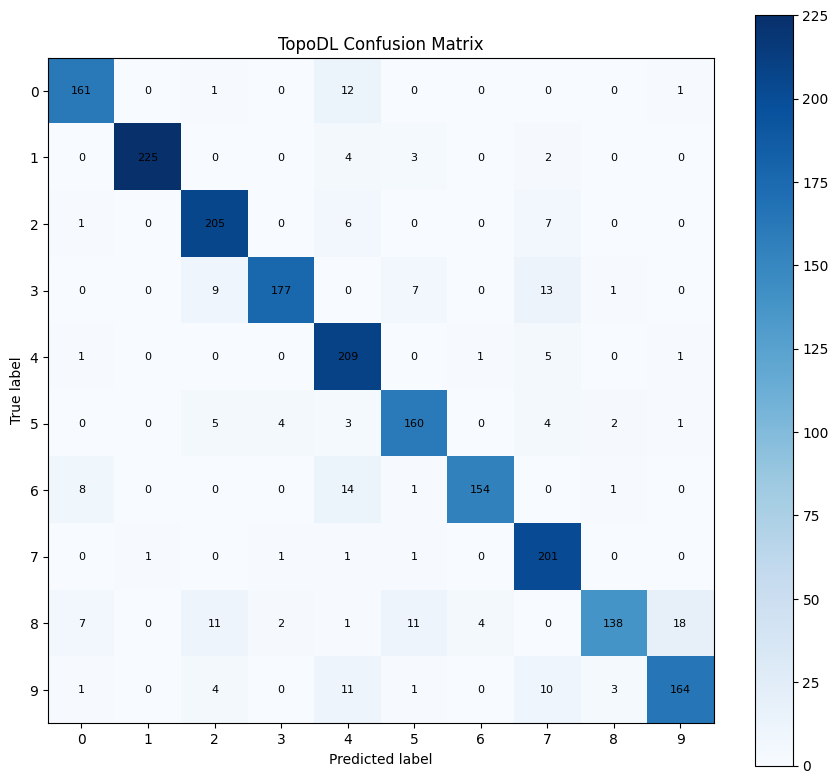

In [15]:
test_loss, test_acc, test_predictions, test_labels = evaluate(
    model, test_loader, criterion, device
)

print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")
print("\nClassification report:")
print(classification_report(test_labels, test_predictions, target_names=class_names, digits=4))

cm = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(9, 8))
plt.imshow(cm, cmap="Blues")
plt.title("TopoDL Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()

for row in range(NUM_CLASSES):
    for col in range(NUM_CLASSES):
        plt.text(col, row, cm[row, col], ha="center", va="center", fontsize=8)

plt.xticks(range(NUM_CLASSES), class_names)
plt.yticks(range(NUM_CLASSES), class_names)
plt.tight_layout()
plt.show()


## 15. Visualize TopoDL Predictions


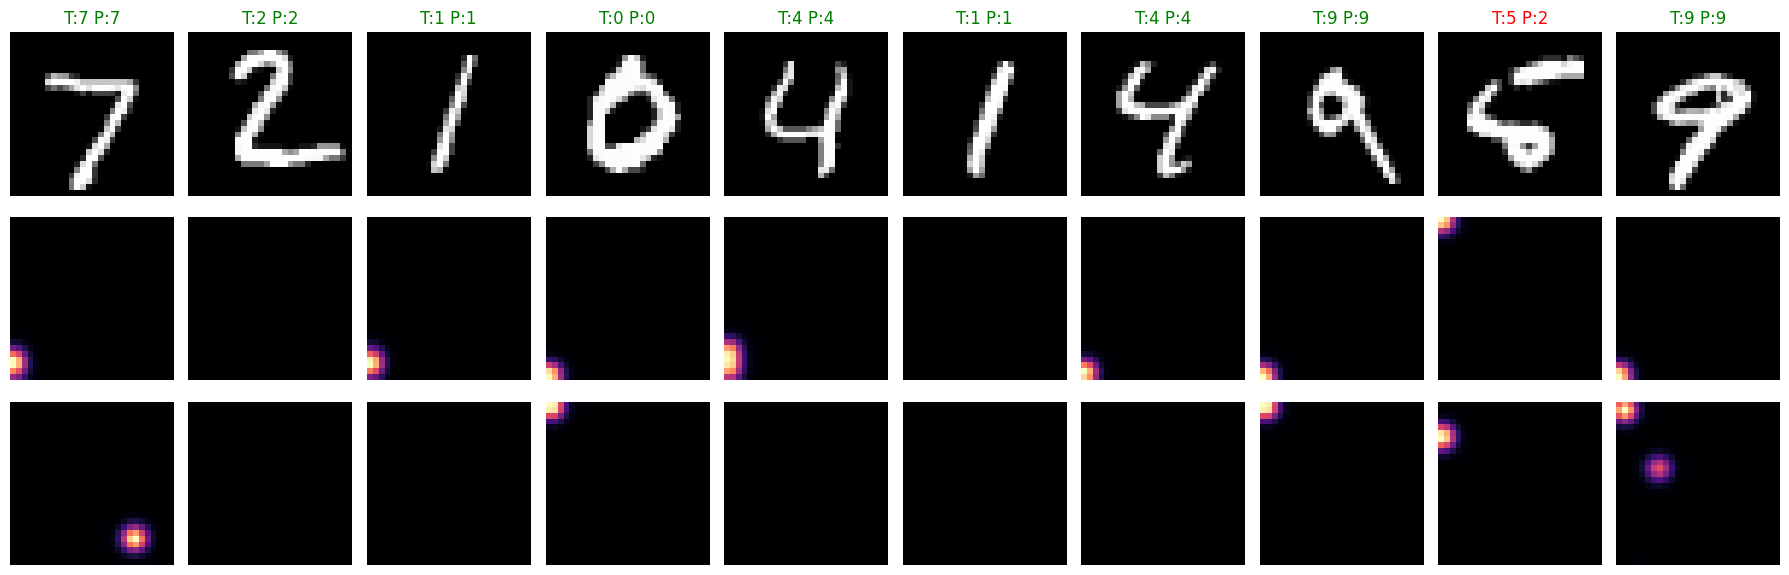

In [16]:
model.eval()
sample_image, sample_h0, sample_h1, sample_labels = next(iter(test_loader))

with torch.no_grad():
    sample_logits = model(
        sample_image.to(device),
        sample_h0.to(device),
        sample_h1.to(device),
    )
    sample_predictions = sample_logits.argmax(dim=1).cpu()

fig, axes = plt.subplots(3, 10, figsize=(18, 6))
for index in range(10):
    true_label = sample_labels[index].item()
    pred_label = sample_predictions[index].item()
    color = "green" if true_label == pred_label else "red"

    original = sample_image[index].squeeze(0).numpy() * 0.3081 + 0.1307
    axes[0, index].imshow(np.clip(original, 0, 1), cmap="gray")
    axes[0, index].set_title(f"T:{true_label} P:{pred_label}", color=color)
    axes[1, index].imshow(sample_h0[index].squeeze(0), cmap="magma", origin="lower")
    axes[2, index].imshow(sample_h1[index].squeeze(0), cmap="magma", origin="lower")

    for row in range(3):
        axes[row, index].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("PI H0")
axes[2, 0].set_ylabel("PI H1")
plt.tight_layout()
plt.show()


## Discussion Questions

1. Why can PI-$H_1$ help distinguish digits containing loops, such as 0, 6, 8, and 9?
2. What information is captured by the PI-$H_0$ branch that may be difficult for a standard CNN?
3. Compare this three-branch model against an image-only CNN using the same image encoder.
4. How do `PI_SIGMA`, PI resolution, and persistence weighting affect classification accuracy?
5. What are the computational and storage costs of caching persistence images for full MNIST?
